# Book - Modern Time Series Forecasting with Python

## Chapter 02 - Data Pre-processing and Feature Engineering


### Python version 3.8

### Libraries version
* matplotlib: 3.7.1
* pandas: 2.0.3
* numpy: 1.24.4
* scipy: 1.10.1
* sklearn: 1.3.2

#### Loading libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import boxcox, yeojohnson
from sklearn.linear_model import LinearRegression

import warnings
warnings.filterwarnings('ignore')

#### Basic imputation techniques 

In [2]:
# Sample time series with missing values
data = {'value': [10, 12, None, 15, 18, None, None, 20]}
dates = pd.to_datetime(['2024-01-01', '2024-01-02', '2024-01-03', '2024-01-04',
                        '2024-01-05', '2024-01-06', '2024-01-07', '2024-01-08'])
ts = pd.Series(data['value'], index=dates)

# Forward fill
ts_ffill = ts.ffill()
print("\n  ======     Forward fill    ====== \n ")
print(ts_ffill.head(10))

# Backward fill
ts_bfill = ts.bfill()
print("\n  ======     Backward fill    ====== \n ")
print(ts_bfill.head(10))

# Interpolate
ts_linear = ts.interpolate(method='linear')
print("\n  ======     Interpolate    ====== \n ")
print(ts_linear.head(10))


  ======     Forward fill    ====== 
 
2024-01-01    10.0
2024-01-02    12.0
2024-01-03    12.0
2024-01-04    15.0
2024-01-05    18.0
2024-01-06    18.0
2024-01-07    18.0
2024-01-08    20.0
dtype: float64

  ======     Backward fill    ====== 
 
2024-01-01    10.0
2024-01-02    12.0
2024-01-03    15.0
2024-01-04    15.0
2024-01-05    18.0
2024-01-06    20.0
2024-01-07    20.0
2024-01-08    20.0
dtype: float64

  ======     Interpolate    ====== 
 
2024-01-01    10.000000
2024-01-02    12.000000
2024-01-03    13.500000
2024-01-04    15.000000
2024-01-05    18.000000
2024-01-06    18.666667
2024-01-07    19.333333
2024-01-08    20.000000
dtype: float64


#### Common transformations for time series

In [3]:
# Sample time series (replace with your data)
data = {'value': [10, 20, 40, 80, 160]}
dates = pd.to_datetime(['2024-01-01', '2024-01-02', '2024-01-03', '2024-01-04', '2024-01-05'])
ts = pd.Series(data['value'], index=dates)
print("\n  ======     Original data    ====== \n ")
print(ts)

# Log transformation
ts_log = np.log(ts)
print("\n  ======     Log transformation    ====== \n ")
print(ts_log)

# Box-Cox transformation (only for positive data)
ts_boxcox, lambda_boxcox = boxcox(ts[ts>0])
print("\n  ======     Box-Cox transformation   ====== \n ")
print(ts_boxcox)

# Yeo-Johnson transformation (handles positive, negative and zero values)
ts_yeojohnson, lambda_yeojohnson = yeojohnson(ts)
print("\n  ======     Yeo-Johnson transformation    ====== \n ")
print(ts_yeojohnson)


  ======     Original data    ====== 
 
2024-01-01     10
2024-01-02     20
2024-01-03     40
2024-01-04     80
2024-01-05    160
dtype: int64

  ======     Log transformation    ====== 
 
2024-01-01    2.302585
2024-01-02    2.995732
2024-01-03    3.688879
2024-01-04    4.382027
2024-01-05    5.075174
dtype: float64

  ======     Box-Cox transformation   ====== 
 
[2.30258508 2.99573224 3.68887941 4.38202657 5.07517373]

  ======     Yeo-Johnson transformation    ====== 
 
[2.33925833 2.95041447 3.57419645 4.20018323 4.82286496]


#### Interpolation techniques for time series

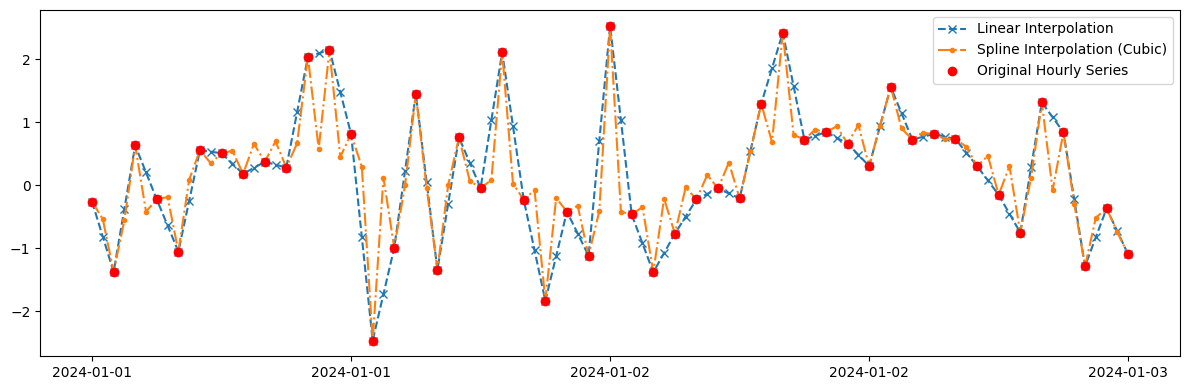

In [4]:
# Create a sample time series (hourly data)
dates = pd.date_range('2024-01-01', '2024-01-03', freq='H')
data = np.random.randn(len(dates))
ts = pd.Series(data, index=dates)

# Downsample to daily frequency, taking the mean
daily_mean = ts.resample('D').mean()

# Downsample to daily frequency, taking the sum
daily_sum = ts.resample('D').sum()

# Upsample to 30-minute frequency using asfreq()
ts_30min = ts.asfreq('30Min')

# Using the upsampled series from before
ts_30min_linear = ts_30min.interpolate(method='linear')  # Linear interpolation
ts_30min_spline = ts_30min.interpolate(method='spline', order=3)  # Cubic spline interpolation


# Create plots
fig, axs = plt.subplots(1, 1, figsize=(12, 4), sharex=True)

# Plot original hourly series

#axs.plot(daily_mean, label='Daily Mean', marker='o')
axs.plot(ts_30min_linear, label='Linear Interpolation', linestyle='--', marker='x')
axs.plot(ts_30min_spline, label='Spline Interpolation (Cubic)', linestyle='-.', marker='.')
axs.plot(ts, label='Original Hourly Series', linestyle='', marker='o',color='red')
axs.legend()

axs.set_xticks(ts.index[::12])  # Show every 12th hour for clarity
axs.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

#### Outlier detection techniques

Outliers (Z-score):
 2024-01-07    190
dtype: int64

Outliers (IQR):
 2024-01-05     40
2024-01-07    190
dtype: int64


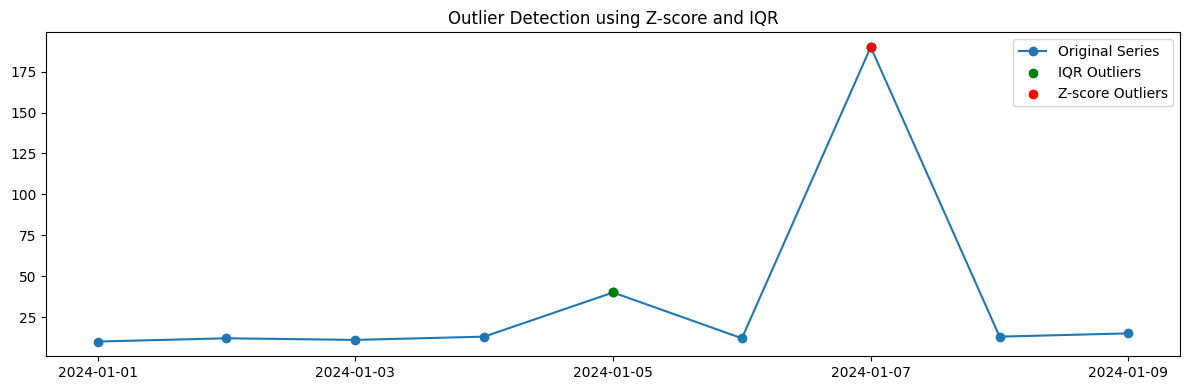

In [5]:
# Sample time series with an outlier
data = {'value': [10, 12, 11, 13, 40, 12, 190, 13, 15]}  # Outlier at index 4
dates = pd.to_datetime(['2024-01-01', '2024-01-02', '2024-01-03', '2024-01-04',
                        '2024-01-05', '2024-01-06', '2024-01-07', '2024-01-08',
                        '2024-01-09'])
ts = pd.Series(data['value'], index=dates)

# Z-score method
z_scores = np.abs((ts - ts.mean()) / ts.std())
outliers_z = ts[z_scores > 2]  # Using a threshold of 2

# IQR method
Q1 = ts.quantile(0.25)
Q3 = ts.quantile(0.75)
IQR = Q3 - Q1
outliers_iqr = ts[(ts < Q1 - 1.5 * IQR) | (ts > Q3 + 1.5 * IQR)]

print("Outliers (Z-score):\n", outliers_z)
print("\nOutliers (IQR):\n", outliers_iqr)

# Plot with decluttered x-axis
plt.figure(figsize=(12, 4))
plt.plot(ts, label='Original Series', marker='o')
plt.scatter(outliers_iqr.index, outliers_iqr, color='green', label='IQR Outliers', zorder=3)
plt.scatter(outliers_z.index, outliers_z, color='red', label='Z-score Outliers', zorder=3)

plt.legend()
plt.title('Outlier Detection using Z-score and IQR')

# Reduce x-axis clutter
plt.xticks(ts.index[::2], rotation=0)  # Show every second date

plt.tight_layout()
plt.show()

#### Lag features

In [6]:
# Create a sample time series
dates = pd.date_range('2023-01-01', periods=10, freq='D')
data = np.arange(10) + np.random.randn(10) * 0.5
ts = pd.Series(data, index=dates)

# Create lag features
ts_df = pd.DataFrame(ts, columns=['value'])
ts_df['lag_1'] = ts_df['value'].shift(1)
ts_df['lag_2'] = ts_df['value'].shift(2)
ts_df['lag_3'] = ts_df['value'].shift(3)

print(ts_df)

               value     lag_1     lag_2     lag_3
2023-01-01 -0.902808       NaN       NaN       NaN
2023-01-02 -0.161006 -0.902808       NaN       NaN
2023-01-03  1.809990 -0.161006 -0.902808       NaN
2023-01-04  3.339354  1.809990 -0.161006 -0.902808
2023-01-05  4.207999  3.339354  1.809990 -0.161006
2023-01-06  4.986867  4.207999  3.339354  1.809990
2023-01-07  5.263659  4.986867  4.207999  3.339354
2023-01-08  6.844427  5.263659  4.986867  4.207999
2023-01-09  7.816754  6.844427  5.263659  4.986867
2023-01-10  8.599803  7.816754  6.844427  5.263659


#### Common rolling window statistics

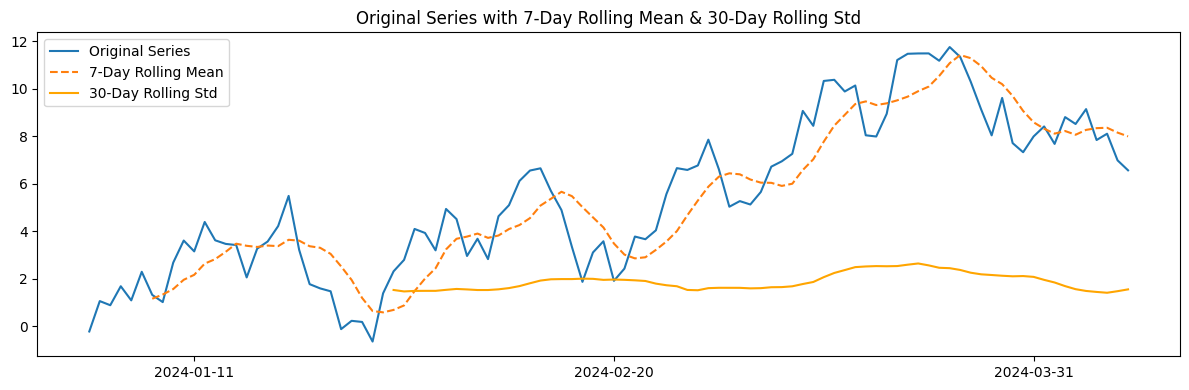

In [7]:
# Create a sample time series
dates = pd.date_range('2024-01-01', periods=100, freq='D')
data = np.random.randn(100).cumsum()  # Cumulative sum of random numbers
ts = pd.Series(data, index=dates)

# Calculate the 7-day rolling mean
rolling_mean = ts.rolling(window=7).mean()

# Calculate the 30-day rolling standard deviation
rolling_std = ts.rolling(window=30).std()

# Create plots in a vertical layout
fig, axs = plt.subplots(1, 1, figsize=(12, 4), sharex=True)

# Plot original series with rolling mean
axs.plot(ts, label='Original Series')
axs.plot(rolling_mean, label='7-Day Rolling Mean', linestyle='--')
axs.plot(rolling_std, label='30-Day Rolling Std', color='orange')
axs.legend()
axs.set_title('Original Series with 7-Day Rolling Mean & 30-Day Rolling Std')


# Reduce x-axis clutter
axs.set_xticks(ts.index[10::40])  # Show every 10th date
axs.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

#### Time-based features

In [8]:
# Create a sample time series
dates = pd.date_range('2024-01-01', '2024-12-31', freq='D')
data = np.random.randn(len(dates))
ts = pd.Series(data, index=dates)
df = pd.DataFrame(ts, columns=['value'])

# Extract cyclical features
df['day_of_week'] = df.index.dayofweek
df['day_of_month'] = df.index.day
df['week_of_year'] = df.index.isocalendar().week
df['month'] = df.index.month
df['quarter'] = df.index.quarter
df['year'] = df.index.year

# Sine/cosine transformations
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

# Create a holiday indicator (example: New Year's Day)
df['is_new_year'] = (df.index.month == 1) & (df.index.day == 1)

# Create a weekend indicator
df['is_weekend'] = df['day_of_week'].isin([5, 6])  # 5: Saturday, 6: Sunday

# Example: Time since/until a specific date (e.g., a marketing campaign)
campaign_date = pd.to_datetime('2024-07-15')
df['days_since_campaign'] = (df.index - campaign_date).days
df['days_until_campaign'] = (campaign_date - df.index).days
# Replace with 0 if the date is before/ after campaign date, respectively
df['days_since_campaign'] = df['days_since_campaign'].apply(lambda x: x if x >= 0 else 0)
df['days_until_campaign'] = df['days_until_campaign'].apply(lambda x: x if x >= 0 else 0)


display(df.head())


,value,day_of_week,day_of_month,week_of_year,month,quarter,year,month_sin,month_cos,is_new_year,is_weekend,days_since_campaign,days_until_campaign
2024-01-01,-0.066787,0,1,1,1,1,2024,0.5,0.866025,True,False,0,196
2024-01-02,-0.912096,1,2,1,1,1,2024,0.5,0.866025,False,False,0,195
2024-01-03,-0.847924,2,3,1,1,1,2024,0.5,0.866025,False,False,0,194
2024-01-04,2.031291,3,4,1,1,1,2024,0.5,0.866025,False,False,0,193
2024-01-05,1.342758,4,5,1,1,1,2024,0.5,0.866025,False,False,0,192


#### Making time series data stationary

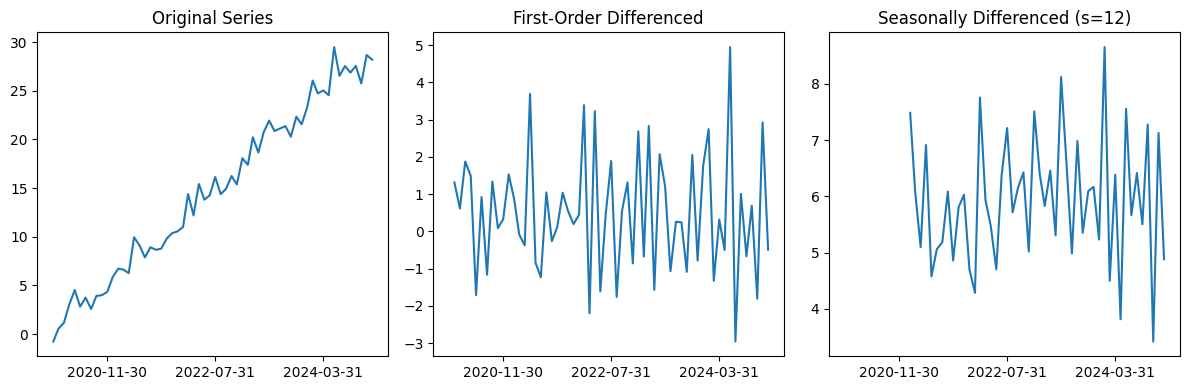

In [9]:
# Create a sample time series with a linear trend and seasonality
dates = pd.date_range('2020-01-01', '2024-12-31', freq='M')
data = np.arange(len(dates)) * 0.5 + np.sin(np.arange(len(dates)) * 2 * np.pi / 12) + np.random.randn(len(dates))
ts = pd.Series(data, index=dates)

# First-order differencing
ts_diff1 = ts.diff().dropna()

# Seasonal differencing (assuming monthly data, s=12)
ts_diff_seasonal = ts.diff(periods=12).dropna()

# Plot the original and differenced series in a vertical layout
fig, axs = plt.subplots(1, 3, figsize=(12, 4), sharex=True)

# Plot original series
axs[0].plot(ts)
axs[0].set_title('Original Series')

# Plot first-order differenced series
axs[1].plot(ts_diff1)
axs[1].set_title('First-Order Differenced')

# Plot seasonally differenced series
axs[2].plot(ts_diff_seasonal)
axs[2].set_title('Seasonally Differenced (s=12)')

# Reduce x-axis clutter
axs[2].set_xticks(ts.index[10::20]) 
axs[2].tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

#### Detrending

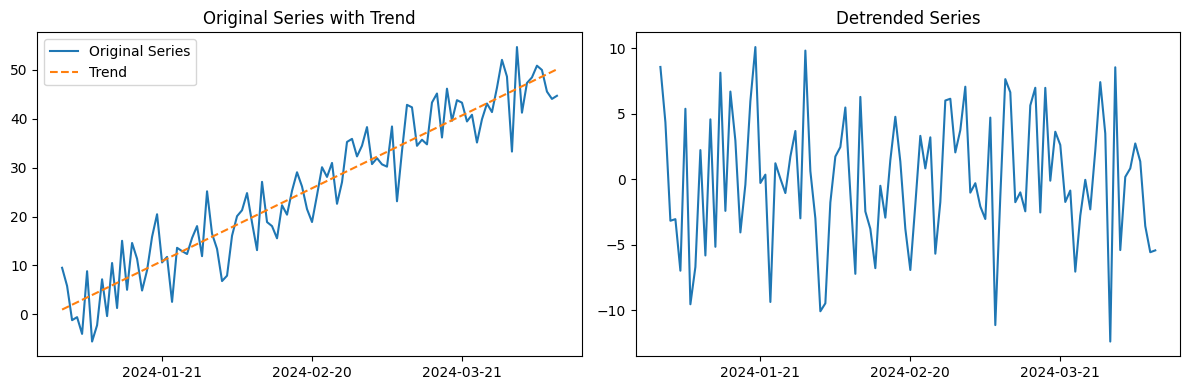

In [10]:
# Create a sample time series with a linear trend
dates = pd.date_range('2024-01-01', periods=100, freq='D')
data = np.arange(100) * 0.5 + np.random.randn(100) * 5  # Linear trend + noise
ts = pd.Series(data, index=dates)

# Create a time index variable
time_index = np.arange(len(ts)).reshape(-1, 1)

# Fit a linear regression model
model = LinearRegression()
model.fit(time_index, ts)

# Predict the trend
trend = model.predict(time_index)

# Detrend the series
ts_detrended = ts - trend

# Plot the results
fig, axs = plt.subplots(1, 2, figsize=(12, 4), sharex=True)

# Plot original series with trend
axs[0].plot(ts, label='Original Series')
axs[0].plot(ts.index, trend, label='Trend', linestyle='--')
axs[0].legend()
axs[0].set_title('Original Series with Trend')

# Plot detrended series
axs[1].plot(ts_detrended)
axs[1].set_title('Detrended Series')

# Reduce x-axis clutter
axs[1].set_xticks(ts.index[20::30])  
axs[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()